# Regional economic-sentiment index — Huila, Colombia

I build a sentiment index from regional economic news, classifying each item with an LLM (Google Gemini) and aggregating the result over time.

**Own approach:** LLM classification (reads context, not just keywords) · regional scope · stated bias.
**Index method:** simple — (% positive − % negative) per period.

> The news are in Spanish (regional outlets), so the classification prompt is kept in Spanish; all analysis code and notes are in English.


In [1]:
# News dataset produced by a separate scraping step (kept private).
# Columns come from the source in Spanish: año, mes, día, medio, titulo, contenido, url.
import pandas as pd

df = pd.read_excel("data.xlsx")
df["date"] = pd.to_datetime(dict(year=df["año"], month=df["mes"], day=df["día"]))

# Data cleaning: the scraper caught some articles twice (pagination overlap). Drop duplicates.
df = df.drop_duplicates(subset="url").reset_index(drop=True)
df = df[["date", "medio", "titulo", "contenido"]].sort_values("date").reset_index(drop=True)

print(f"{len(df)} unique news items, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


43 unique news items, 2026-07-01 to 2026-07-21


,date,medio,titulo,contenido
0,2026-07-01,Diario La Nación,Banco de la República sube la tasa de interés ...,Banco de la República sube la tasa de interés ...
1,2026-07-01,Diario La Nación,Neiva: tercera ciudad con menos desempleo del ...,Neiva: tercera ciudad con menos desempleo del ...
2,2026-07-02,Diario La Nación,SOS en exportadores.,SOS en exportadores.\n\nQue el dólar se haya a...
3,2026-07-02,Diario La Nación,74 empresas del Huila entre las 10.000 más gra...,74 empresas del Huila entre las 10.000 más gra...
4,2026-07-02,Diario La Nación,La protesta de Anato.,La protesta de Anato.\n\nLa Asociación Colombi...


In [2]:
# Connect to Gemini. The API key is requested at runtime and never stored in the notebook.
from google import genai
import getpass

client = genai.Client(api_key=getpass.getpass("Paste your Gemini API key: "))
print("Client ready")


Client ready


In [3]:
# Classify the economic sentiment of a news item as positive / negative / neutral.
# Prompt is in Spanish because the news is in Spanish; the LLM reads the full context.
def classify_sentiment(title, body):
    prompt = f"""Clasifica el SENTIMIENTO ECONÓMICO de esta noticia según su impacto sobre la economía regional.
Responde SOLO una palabra: positivo, negativo o neutral.

- positivo: mejora económica (crecimiento, empleo, inversión, exportaciones al alza).
- negativo: deterioro (caída, desempleo, cierre, inflación, crisis).
- neutral: informativo sin dirección clara, o efectos mixtos.

Título: {title}
Contenido: {body[:800]}

Respuesta (una palabra):"""
    r = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    return r.text.strip().lower()

# Quick check on the first item
classify_sentiment(df.loc[0, "titulo"], df.loc[0, "contenido"])


'negativo'

In [4]:
# Classify every item (one API call each; prints progress).
import time

labels = []
for i, row in df.iterrows():
    s = classify_sentiment(row["titulo"], row["contenido"])
    labels.append(s)
    print(f"{i+1}/{len(df)}  ->  {s:9} | {row['titulo'][:55]}")
    time.sleep(0.5)

df["sentiment"] = labels
df["sentiment"].value_counts()


1/43  ->  negativo  | Banco de la República sube la tasa de interés al 12%.
2/43  ->  positivo  | Neiva: tercera ciudad con menos desempleo del país, seg
3/43  ->  negativo  | SOS en exportadores.
4/43  ->  positivo  | 74 empresas del Huila entre las 10.000 más grandes del 
5/43  ->  negativo  | La protesta de Anato.
6/43  ->  negativo  | Tasa amarga: el dólar barato golpea a exportadores huil
7/43  ->  positivo  | Plata de los cafeteros seguirá en manos de la Federació
8/43  ->  negativo  | Arancel a importación de vidrio.
9/43  ->  negativo  | Los cafeteros huilenses no esperan una buena cosecha en
10/43  ->  negativo  | El impuesto silencioso de la revaluación.
11/43  ->  positivo  | La economía del Huila crece por quinto año consecutivo.
12/43  ->  neutral   | ¿Qué le espera a la economía del Huila con De La Esprie
13/43  ->  negativo  | Días cruciales para evitar un apagón durante El Niño.
14/43  ->  positivo  | Desde $30 mil, la camiseta de la Selección en Neiva.
15/43  ->  negat

sentiment
negativo    18
positivo    17
neutral      8
Name: count, dtype: int64

In [5]:
# Index = (% positive - % negative), scaled -100 (all bad) to +100 (all good).
def sentiment_index(group):
    n = len(group)
    return (group.eq("positivo").sum() - group.eq("negativo").sum()) / n * 100

overall = sentiment_index(df["sentiment"])
print(f"Sentiment index — Huila, July 2026: {overall:+.1f}")

# Daily index to see the evolution across the month.
daily = df.groupby(df["date"].dt.date)["sentiment"].apply(sentiment_index)
daily


Sentiment index — Huila, July 2026: -2.3


date
2026-07-01      0.000000
2026-07-02    -33.333333
2026-07-03    -33.333333
2026-07-04   -100.000000
2026-07-05   -100.000000
2026-07-06     50.000000
2026-07-07      0.000000
2026-07-08   -100.000000
2026-07-09    100.000000
2026-07-10      0.000000
2026-07-11      0.000000
2026-07-12    -33.333333
2026-07-13    100.000000
2026-07-14      0.000000
2026-07-15     25.000000
2026-07-16   -100.000000
2026-07-17      0.000000
2026-07-18     50.000000
2026-07-20      0.000000
2026-07-21     50.000000
Name: sentiment, dtype: float64

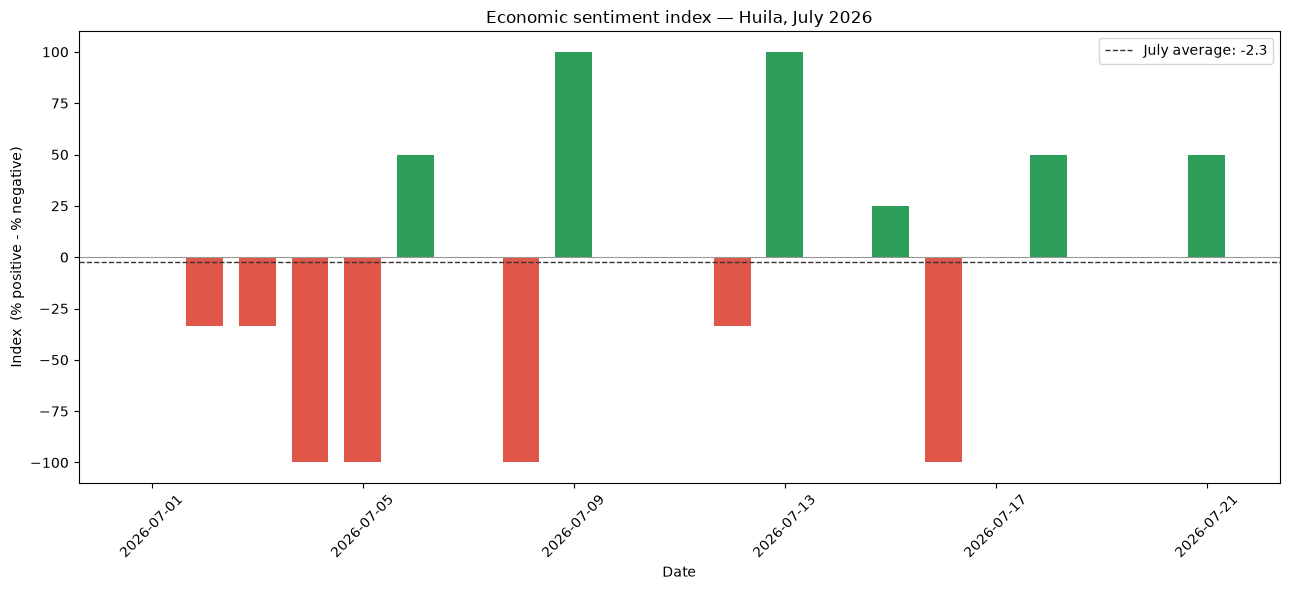

In [6]:
# Daily index: green bars = positive days, red = negative; dashed line = monthly average.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))
colors = ["#2e9e5b" if v >= 0 else "#e0574a" for v in daily.values]
ax.bar(daily.index, daily.values, color=colors, width=0.7)
ax.axhline(overall, color="#333", linestyle="--", linewidth=1, label=f"July average: {overall:+.1f}")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_title("Economic sentiment index — Huila, July 2026")
ax.set_ylabel("Index  (% positive - % negative)"); ax.set_xlabel("Date")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig.savefig("sentiment_index.png", dpi=120, bbox_inches="tight")


In [7]:
# OPTIONAL — aggregate weekly or monthly to smooth the index as the sample grows.
# The daily view above is volatile because each day has few news items; a coarser
# window (more news per bar) gives a steadier read.
period = "W"          # "W" = weekly, "M" = monthly
agg = df.groupby(df["date"].dt.to_period(period))["sentiment"].apply(sentiment_index)
agg.index = agg.index.astype(str)
print(agg)


date
2026-06-29/2026-07-05   -40.000000
2026-07-06/2026-07-12     0.000000
2026-07-13/2026-07-19    13.333333
2026-07-20/2026-07-26    25.000000
Name: sentiment, dtype: float64


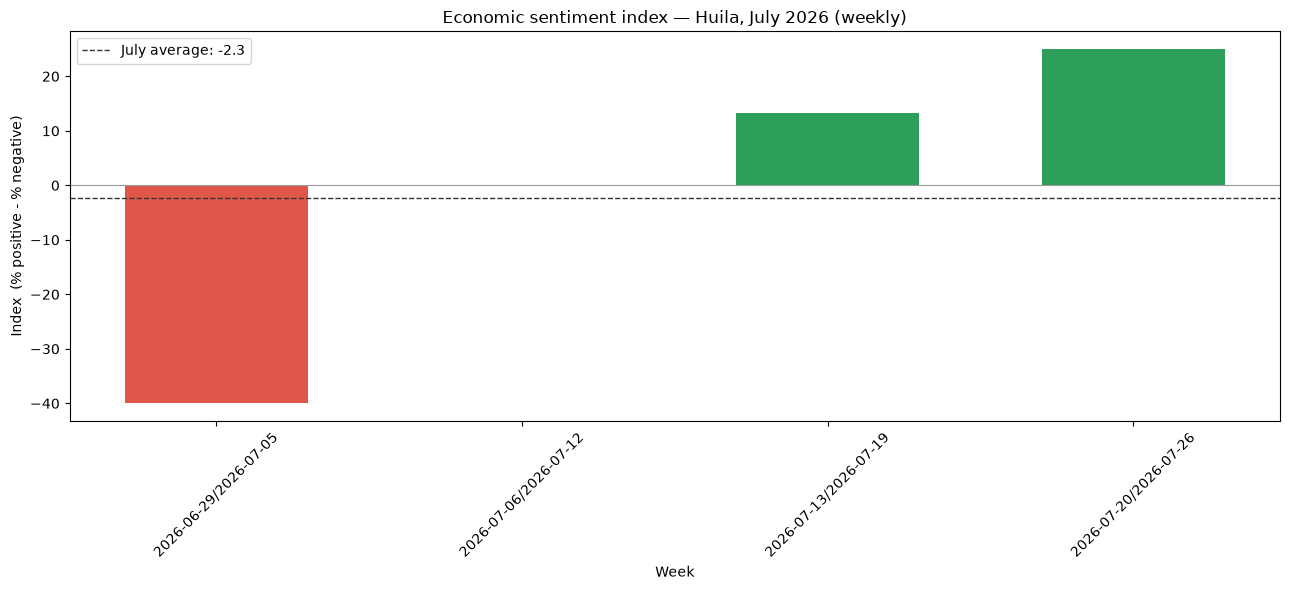

In [9]:
# Aggregated index chart (weekly). Uses `agg` from the optional cell above.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))
colors = ["#2e9e5b" if v >= 0 else "#e0574a" for v in agg.values]
ax.bar(agg.index, agg.values, color=colors, width=0.6)
ax.axhline(overall, color="#333", linestyle="--", linewidth=1, label=f"July average: {overall:+.1f}")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_title("Economic sentiment index — Huila, July 2026 (weekly)")
ax.set_ylabel("Index  (% positive - % negative)"); ax.set_xlabel("Week")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig.savefig("sentiment_index_weekly.png", dpi=120, bbox_inches="tight")